# 발표 그래프 재현 노트북

단계 사다리(fig1 계열)와 노이즈 3선(fig2) 그래프를 **GPU 없이** 재현한다.
수치는 `reports/figure_data.json`(집계본, 커밋됨)에서 읽으며, 이 집계본은
`outputs/`(스코어·judge 산출물)에서 `scripts/make_figures.py --rebuild`로 만들어졌다.

| 그래프 | 데이터 | 비고 |
|---|---|---|
| fig1·fig1b·fig1c | ACI-Bench valid 20건 × 4모델 | 개선3 = 개선2 출력 + 32B 검증기 교정 |
| fig2 (32B/7B) | 김고은 형태노이즈 100건 | soap / soap_hard / soap_fewshot, 노트별 평균 환각률 |

전체 파이프라인 재현(GPU 필요)은 `docs/eval_ladder_day6.md`의 명령 참조.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import scripts.make_figures as mf
data = mf.load_data()
mf.render_all(data)   # docs/figures/ 5장 재생성


[figures] 저장 → /workspace/soap-note-verification/docs/figures/fig1_stage_performance.png
[figures] 저장 → /workspace/soap-note-verification/docs/figures/fig1c_stage_grounded.png


[figures] 저장 → /workspace/soap-note-verification/docs/figures/fig1b_stage_metrics_2x2.png


[figures] 저장 → /workspace/soap-note-verification/docs/figures/fig2_noise_prompts_32b.png


[figures] 저장 → /workspace/soap-note-verification/docs/figures/fig2_noise_prompts_7b.png


## 1. 근거율 단독 — 발표 헤드라인 추천
94.6% → 95.0% → 96.5% → **98.5%** (4모델 평균, 단조 증가)

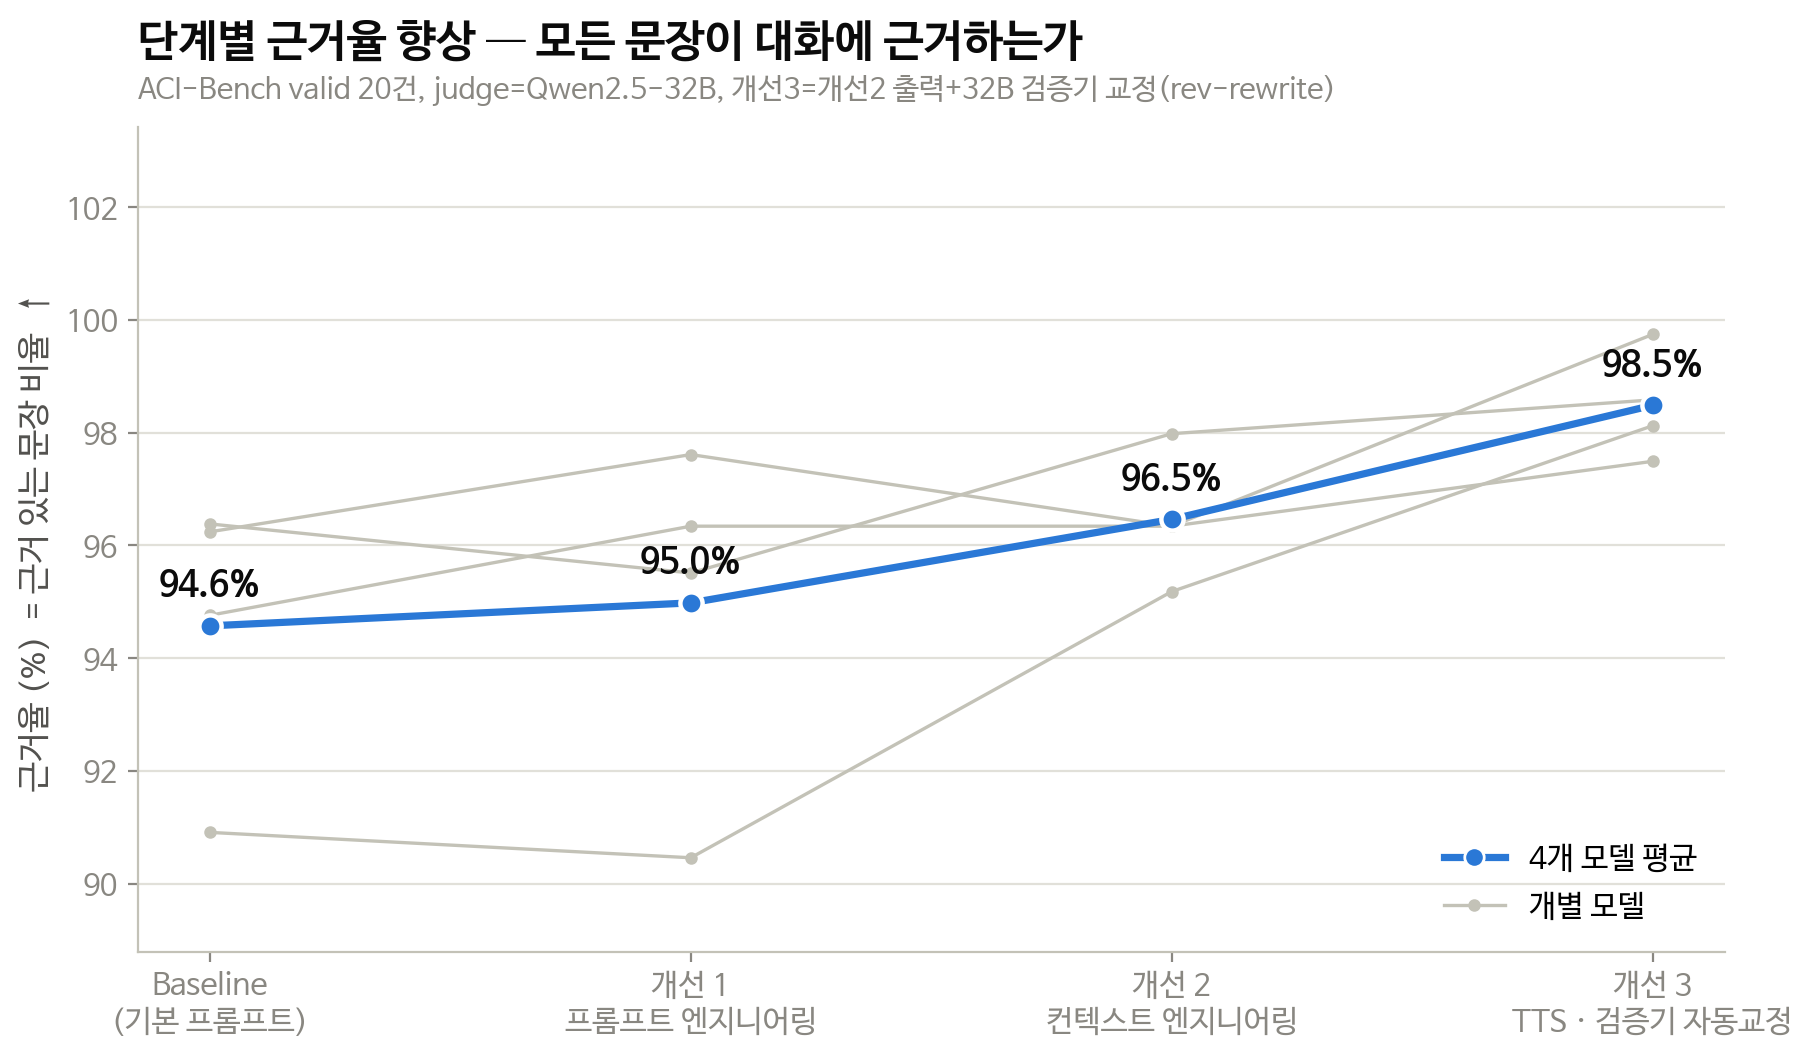

In [2]:
from IPython.display import Image, display
display(Image('../docs/figures/fig1c_stage_grounded.png', width=880))

## 2. ROUGE-1 단독 — "성능 증가" 그래프
0.491 → 0.517 → 0.518 → **0.520**

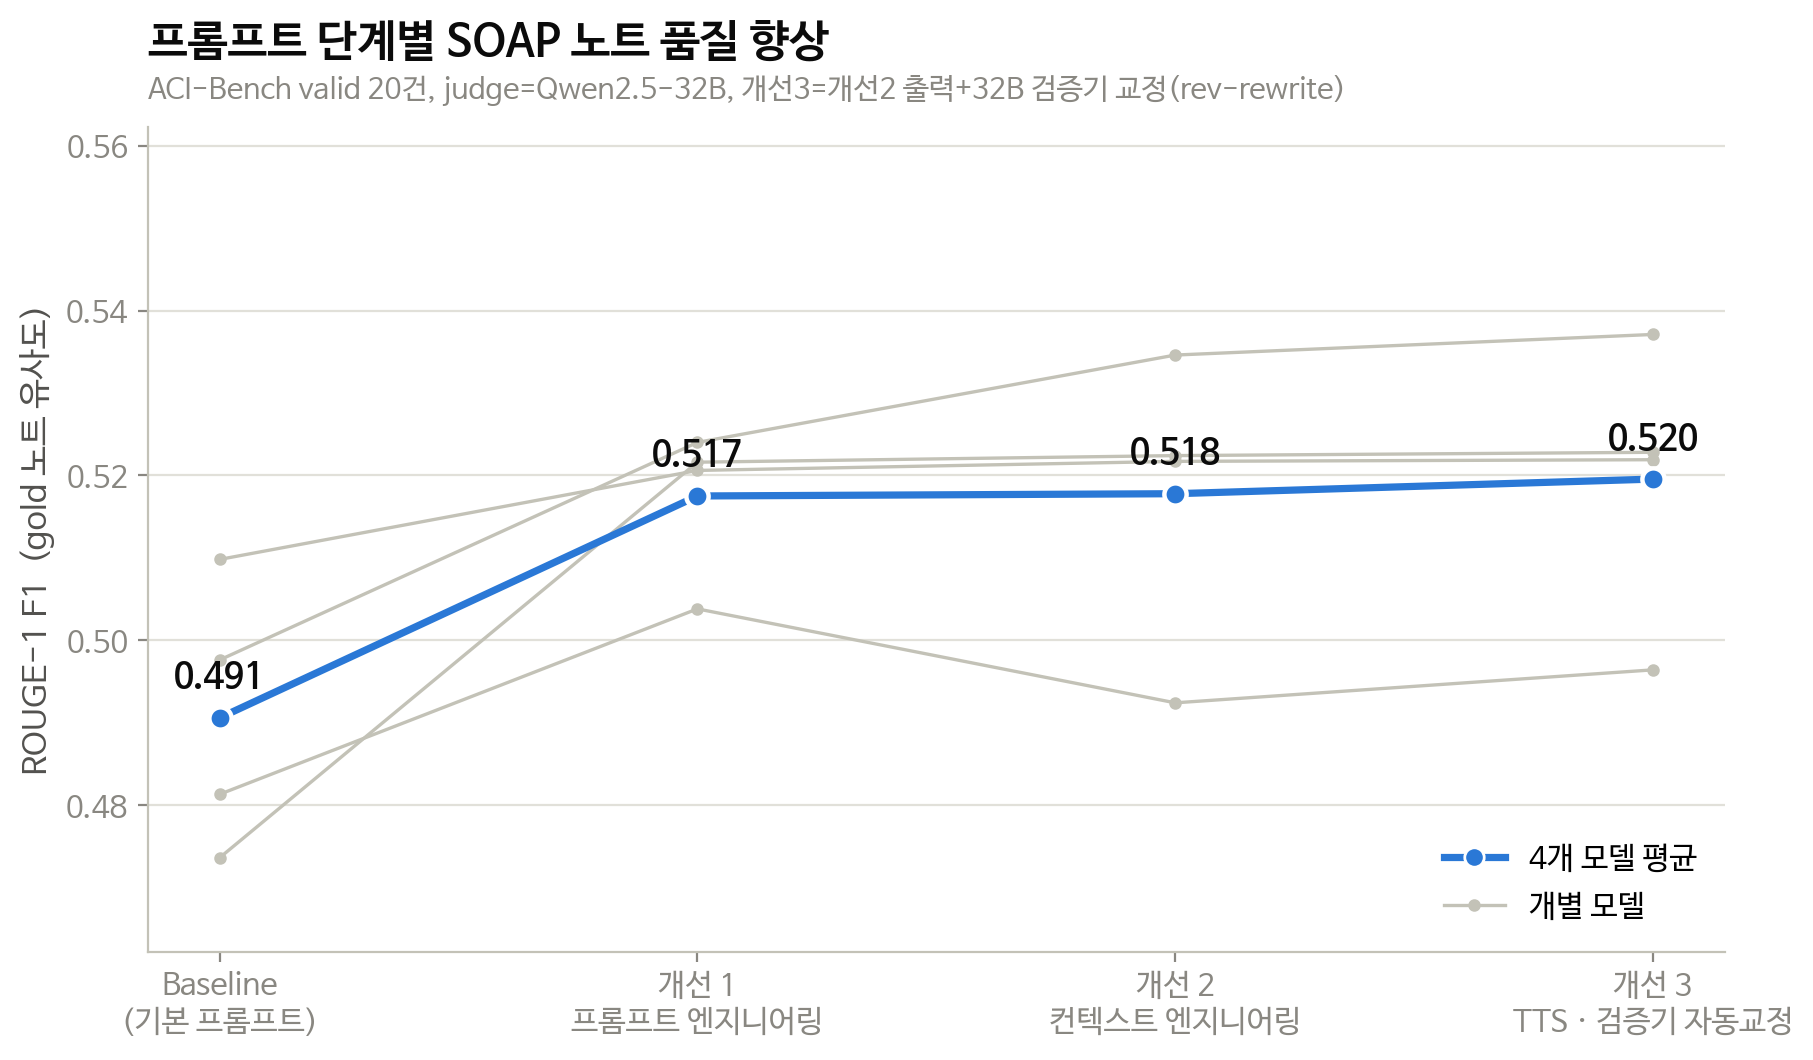

In [3]:
display(Image('../docs/figures/fig1_stage_performance.png', width=880))

## 3. 4개 지표 패널 — 전부 개선 또는 유지
ROUGE-1 ↑ · 구역정렬 유지 · 환각률 5.4→**1.5%** · 인용 정밀도 0.976→**0.987**

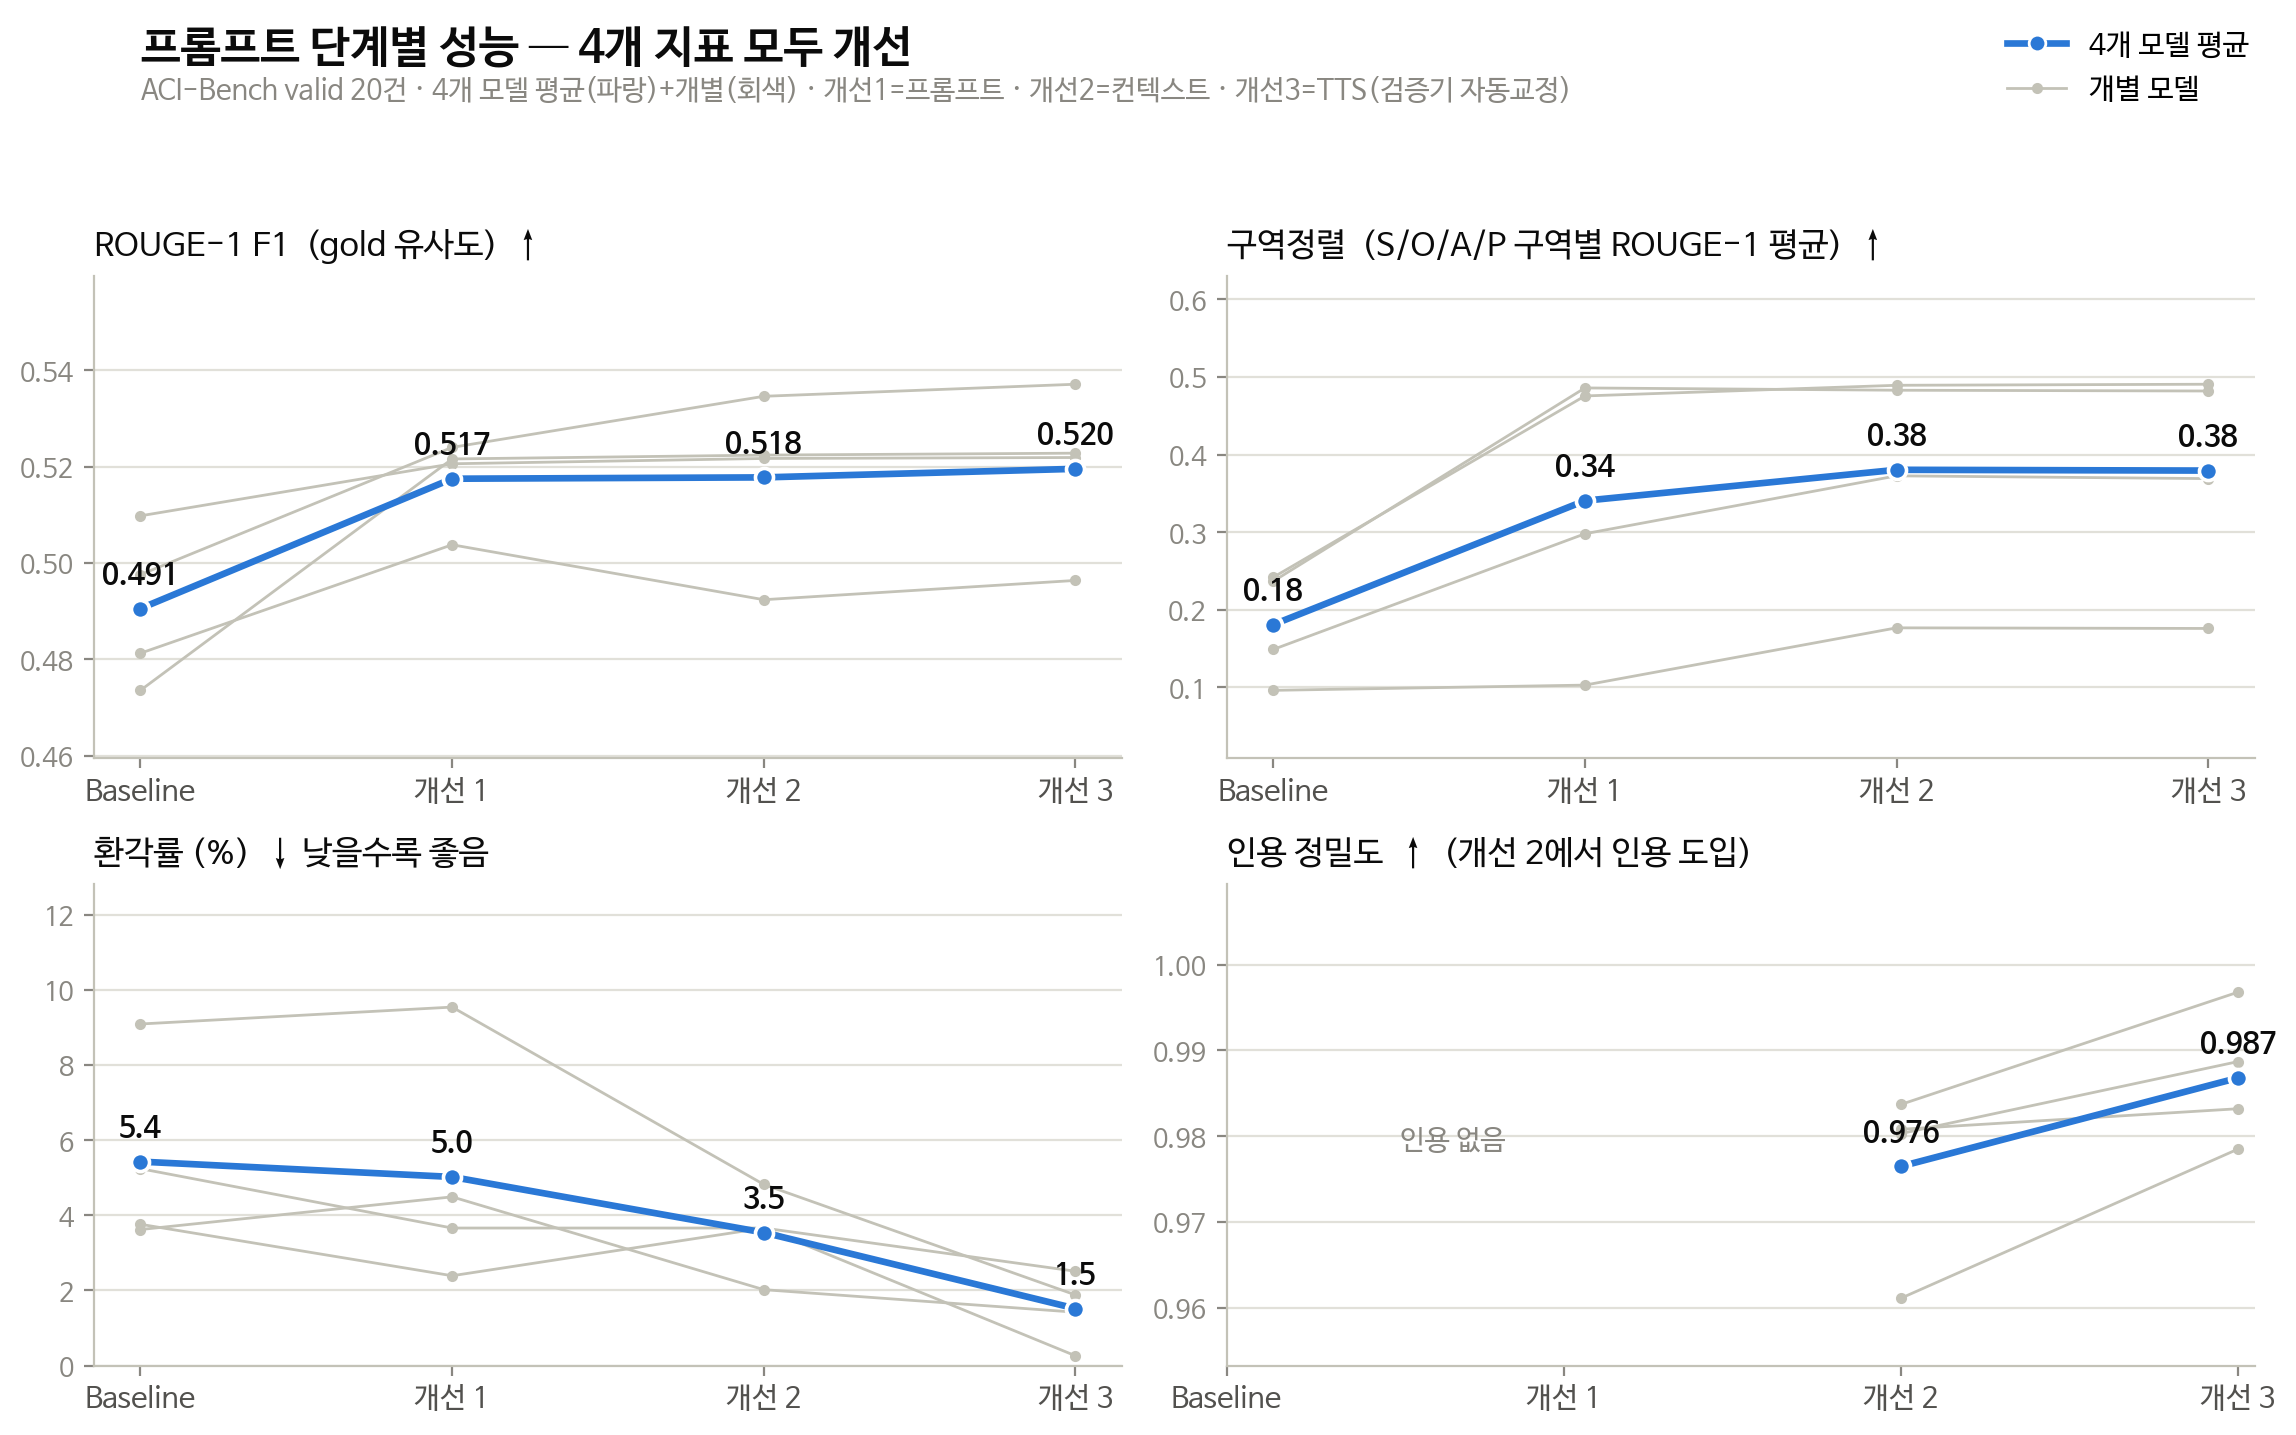

In [4]:
display(Image('../docs/figures/fig1b_stage_metrics_2x2.png', width=980))

## 4. 노이즈 대화 3선 — 규칙 추가는 효과 없음, 예시가 답
32B: soap 5.8% ≈ hard 5.9% → **fewshot 0.4%** (제3화자 0%)

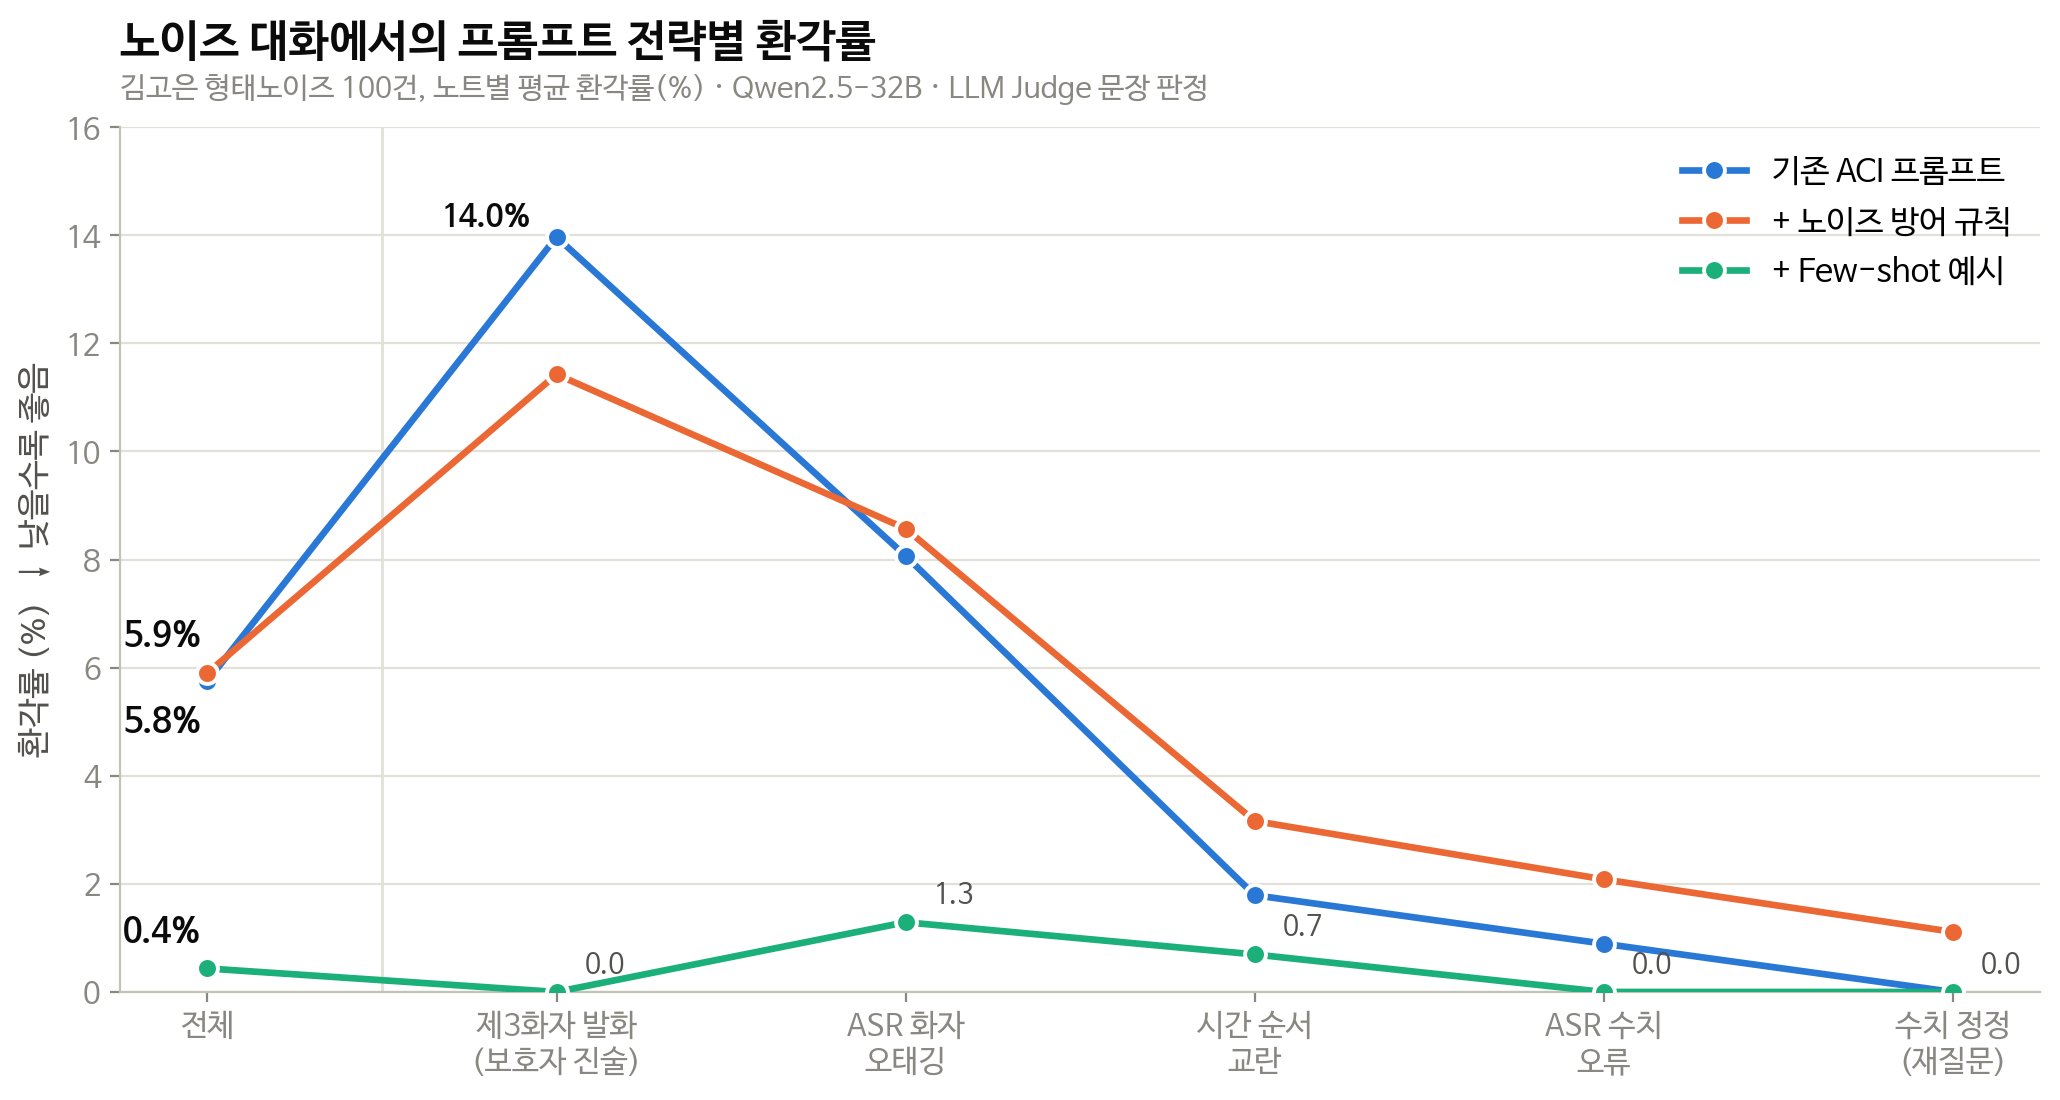

In [5]:
display(Image('../docs/figures/fig2_noise_prompts_32b.png', width=980))

## 5. (보조) 7B — few-shot도 ASR 화자 오태깅에선 악화(21.2%)
분석: `docs/프롬프트부록_케이스분석_0722.pdf` §5 (N_M12 사례)

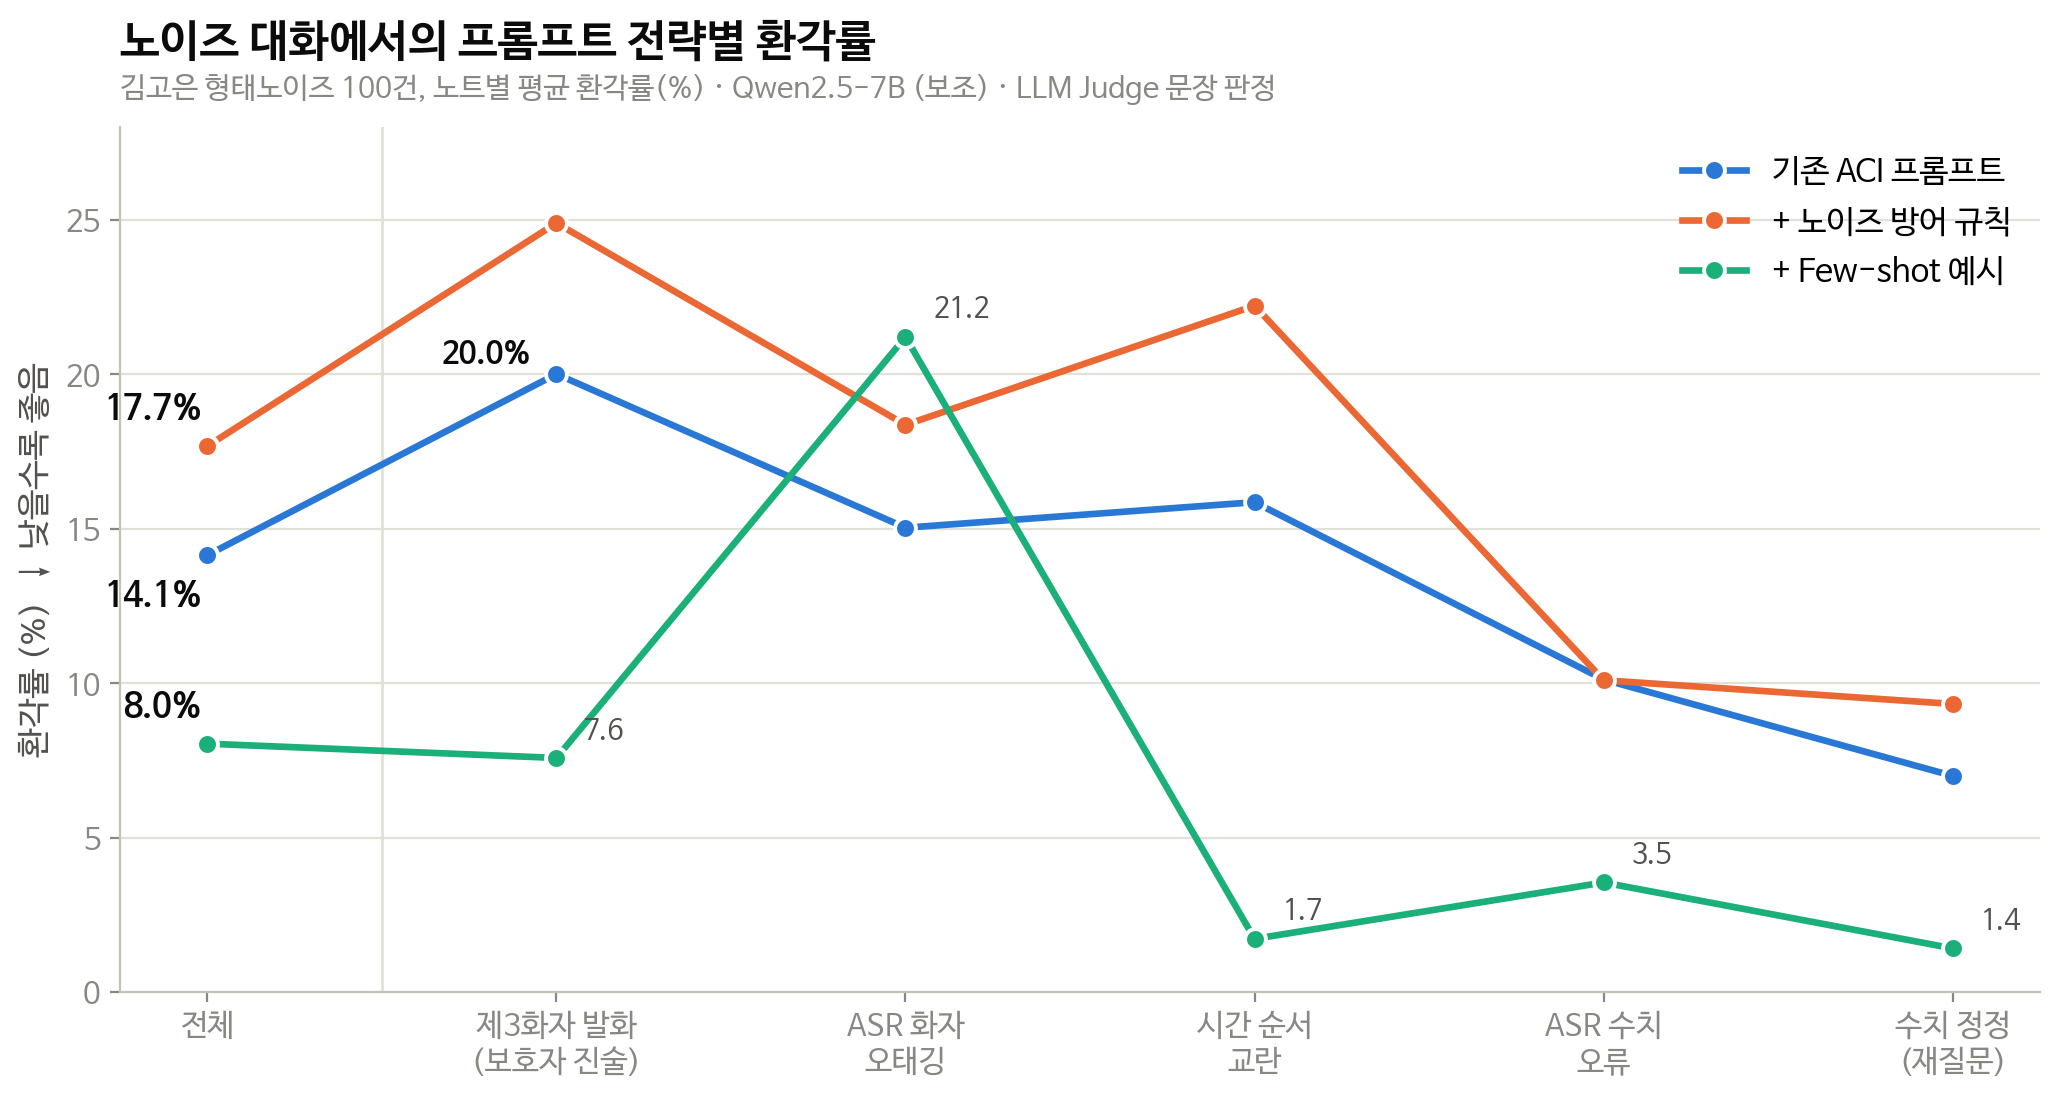

In [6]:
display(Image('../docs/figures/fig2_noise_prompts_7b.png', width=980))

---
### 수치만 다시 뽑고 싶을 때
```python
data['ladder']['hr']            # 모델별 환각률 [baseline, 개선1, 개선2, 개선3]
data['noise']['qwen2.5-32b']    # 노이즈 유형별 환각률
```
`outputs/`를 새로 만들었으면(파이프라인 재실행) 터미널에서:
```bash
.venv/bin/python scripts/make_figures.py --rebuild
```